HANDWRITTEN DIGIT RECOGNITION SYSTEM

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [2]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("New training data shape:", x_train.shape)
print("New label shape:", y_train.shape)


New training data shape: (60000, 28, 28, 1)
New label shape: (60000, 10)


In [3]:
model = models.Sequential([
    # Minimal augmentation for robust learning
    layers.RandomRotation(0.1),
    
    # Layer 1: Extract edges and basic shapes
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1), kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Layer 2: Extract mid-level features
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Dense layers with proper regularization
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer='l2'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model.summary()

C:\Users\simon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.05, momentum=0.95, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=5, 
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 72s 74ms/step - accuracy: 0.8839 - loss: 3.5253 - val_accuracy: 0.9317 - val_loss: 1.4510
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - accuracy: 0.9119 - loss: 1.4628 - val_accuracy: 0.9310 - val_loss: 1.3720
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9114 - loss: 1.4501 - val_accuracy: 0.9499 - val_loss: 1.2915
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9118 - loss: 1.3828 - val_accuracy: 0.9167 - val_loss: 1.3656
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.9121 - loss: 1.3948 - val_accuracy: 0.9300 - val_loss: 1.3272


NUMBER RECOGNIER 

In [5]:
model.save('digit_model.h5')
print("Model saved")

Model saved


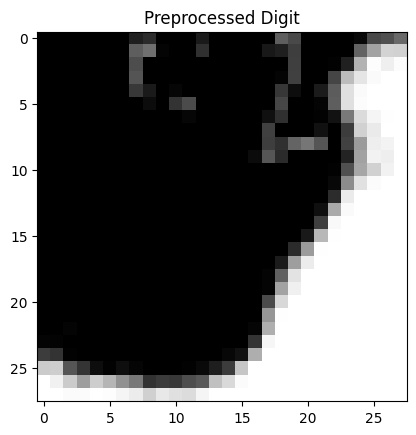

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("captured_digit.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w*h > 100:  # ignore very small noise
        digit = thresh[y:y+h, x:x+w]
        break

resized = cv2.resize(digit, (28, 28), interpolation=cv2.INTER_AREA)

resized = resized.astype('float32') / 255.0
resized = np.reshape(resized, (1, 28, 28, 1))

plt.imshow(resized.reshape(28, 28), cmap='gray')
plt.title("Preprocessed Digit")
plt.show()


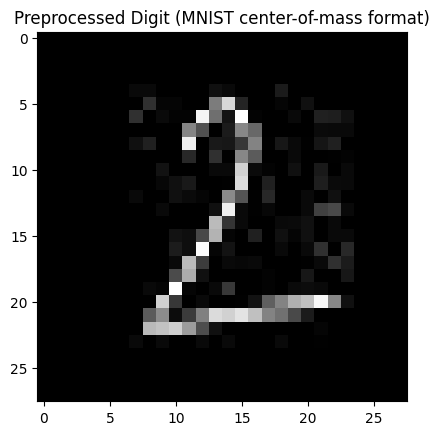

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

img = cv2.imread("captured_digit.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

# # Morphological closing and dilation to thicken digit lines (matches MNIST brush strokes)
# kernel = np.ones((3,3), np.uint8)
# thresh = cv2.dilate(thresh, kernel, iterations=1)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered = [c for c in contours if cv2.contourArea(c) > 150]

if len(filtered) == 0:
    raise ValueError("No clear digit found!")

largest_contour = max(filtered, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest_contour)

# Add small padding to bounding box
padding = 10
img_h, img_w = thresh.shape
x = max(0, x - padding)
y = max(0, y - padding)
w = min(img_w - x, w + 2*padding)
h = min(img_h - y, h + 2*padding)

# Extract the bounding box round the digit
digit = thresh[y:y+h, x:x+w]

# Center using center of mass to match MNIST tightly
side = max(w, h)
scale_factor = 20.0 / side
new_w = int(w * scale_factor)
new_h = int(h * scale_factor)

resized_digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

# Calculate center of mass of the scaled digit
M = cv2.moments(resized_digit)
if M["m00"] != 0:
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
else:
    cX, cY = new_w // 2, new_h // 2

# Create a 28x28 black background
final_img = np.zeros((28, 28), dtype=np.uint8)

# Center of mass should be placed in the middle of the 28x28 image (at 14, 14)
# Calculate where the top left corner needs to sit. 
offset_x = 14 - cX
offset_y = 14 - cY

# Bound checks
if offset_x < 0: offset_x = 0
if offset_y < 0: offset_y = 0
if offset_x + new_w > 28: offset_x = 28 - new_w
if offset_y + new_h > 28: offset_y = 28 - new_h

final_img[offset_y:offset_y+new_h, offset_x:offset_x+new_w] = resized_digit

resized = final_img.astype('float32') / 255.0
resized = np.reshape(resized, (1, 28, 28, 1))

plt.imshow(resized.reshape(28, 28), cmap='gray')
plt.title("Preprocessed Digit (MNIST center-of-mass format)")
plt.show()

In [8]:
from tensorflow.keras.models import load_model
import numpy as np

model = load_model("digit_model.h5")

prediction = model.predict(resized)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Predicted Digit: 1
